# Jalon 2 — Exploration validée

Pisciculture IA — Module 2 (`docs/02-SPEC_TECHNIQUE.md` §3, `docs/04-JALONS_VALIDATION.md` Jalon 2).

Ce notebook est un notebook d'**exploration** : toute la logique réutilisable
vit dans `src/ingestion.py` et `src/features.py` (importés ci-dessous), rien
n'est redéfini ici (`.claude/rules/conventions-code.md`).

Objectifs (critères du Jalon 2) :
1. Distributions avant/après nettoyage, confrontées aux seuils scientifiques du silure.
2. Au moins une figure montrant clairement une période d'anomalie détectable à l'œil.
3. Corrélations entre qualité d'eau et croissance, calculées et interprétées (même faibles).
4. Couverture temporelle réelle des données.
5. Démonstration des features causales (`add_rolling_features`, `add_threshold_distance`, `compute_growth_rate`, `resample_hourly`).
6. Matière factuelle (non tranchée) pour deux décisions ouvertes : resserrement du pH, seuil de turbidité.

Point de vigilance (R16, `docs/08-REGISTRE_RISQUES.md`) : après nettoyage, 28,00 % de
l'ammoniac et 15,93 % de l'oxygène dissous sont manquants ; 11,98 % / 7,25 % des valeurs
*présentes* de DO / ammoniac sont interpolées, pas mesurées. Toute lecture d'une moyenne
ou d'une corrélation impliquant ces deux variables doit être accompagnée de son effectif
réel (`n_measured`) — jamais présentée seule.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, ingestion, features

plt.rcParams["figure.dpi"] = 100
FIGURES_DIR = config.FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Répertoire des figures :", FIGURES_DIR)


Répertoire des figures : C:\Users\Admin\Desktop\Projet_master1\Projet_pisiculture\reports\figures


## 0. Chargement des données

Régénéré en mémoire à partir du CSV brut (`config.RAW_DATA_PATH`), sans écrire
sur `data/raw/` (immuable) : `ingestion.load_raw_data` puis `ingestion.clean_data`,
exactement le pipeline du Jalon 1 (`python -m src.ingestion`).


In [2]:
raw_df = ingestion.load_raw_data(str(config.RAW_DATA_PATH))
clean_df, cleaning_report = ingestion.clean_data(raw_df)

print(f"Brut     : {raw_df.shape[0]:,} lignes x {raw_df.shape[1]} colonnes — SHA-256 {raw_df.attrs['source_sha256'][:12]}...")
print(f"Nettoyé  : {clean_df.shape[0]:,} lignes x {clean_df.shape[1]} colonnes")
print(f"Étendue  : {clean_df[config.TIMESTAMP_COLUMN].min()} -> {clean_df[config.TIMESTAMP_COLUMN].max()}")


rebuild_growth_curve : 3 non-monotonie(s) détectée(s) sur Fish_Length(cm), signalée(s) dans 'Fish_Length_non_monotonic' sans correction : [{'created_at': Timestamp('2021-07-15 00:02:47'), 'Fish_Length(cm)': 15.31}, {'created_at': Timestamp('2021-08-22 01:43:01'), 'Fish_Length(cm)': 23.4}, {'created_at': Timestamp('2021-09-05 00:07:20'), 'Fish_Length(cm)': 12.09}]


Brut     : 83,126 lignes x 11 colonnes — SHA-256 063ea4f0c9fc...
Nettoyé  : 83,126 lignes x 23 colonnes
Étendue  : 2021-06-19 00:00:05 -> 2021-10-13 04:14:22


## 1. Distributions avant / après nettoyage

Les 4 variables bornées (`config.SENSOR_TYPES` avec `bounds` non `None`) : température, pH,
oxygène dissous, ammoniac. Les seuils scientifiques du silure affichés en repère sont ceux de
`config.get_applicable_thresholds()` (température, pH, DO — sondes immergées uniquement,
ADR-009) : jamais un seuil mg/L affiché sur l'ammoniac (capteur de gaz).


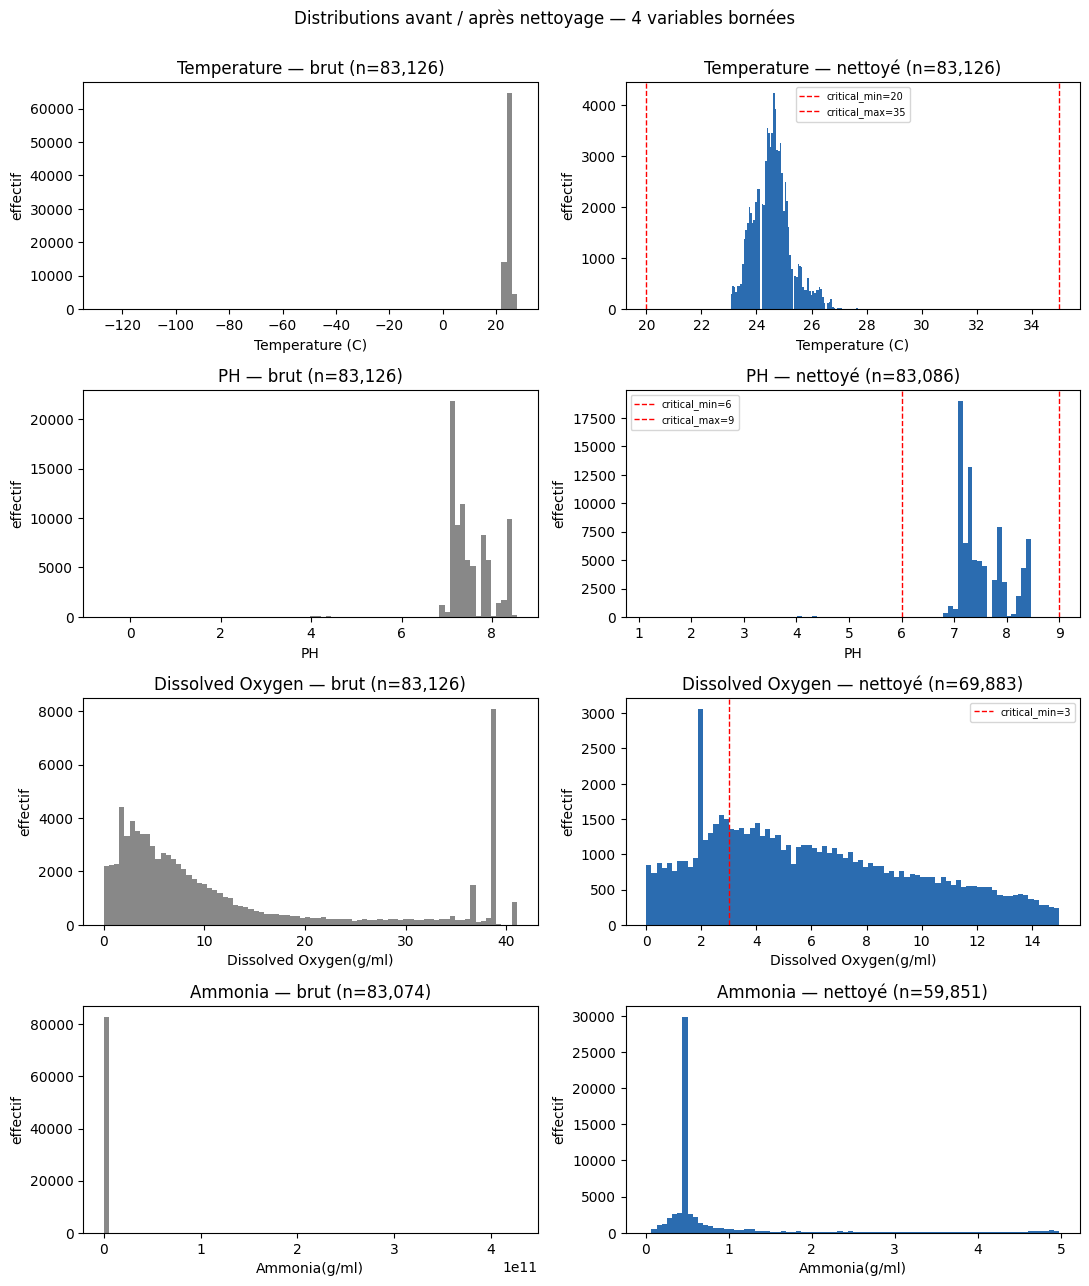

In [3]:
bounded_columns = [
    (raw_col, meta) for raw_col, meta in config.SENSOR_TYPES.items() if meta["bounds"] is not None
]
applicable = config.get_applicable_thresholds()

fig, axes = plt.subplots(len(bounded_columns), 2, figsize=(11, 3.2 * len(bounded_columns)))
for row, (raw_col, meta) in enumerate(bounded_columns):
    label = meta["label"]
    threshold_key = meta["threshold_key"]
    ax_before, ax_after = axes[row]

    ax_before.hist(raw_df[raw_col].dropna(), bins=80, color="#888888")
    ax_before.set_title(f"{label} — brut (n={raw_df[raw_col].notna().sum():,})")

    clean_values = clean_df[raw_col].dropna()
    ax_after.hist(clean_values, bins=80, color="#2b6cb0")
    ax_after.set_title(f"{label} — nettoyé (n={clean_values.shape[0]:,})")

    if threshold_key in applicable:
        bounds = applicable[threshold_key]
        for key in ("critical_min", "critical_max"):
            if bounds.get(key) is not None:
                ax_after.axvline(bounds[key], color="red", linestyle="--", linewidth=1,
                                  label=f"{key}={bounds[key]}")
        ax_after.legend(fontsize=7)

    for ax in (ax_before, ax_after):
        ax.set_xlabel(raw_col)
        ax.set_ylabel("effectif")

fig.suptitle("Distributions avant / après nettoyage — 4 variables bornées", y=1.001)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "jalon2_distributions_avant_apres.png", bbox_inches="tight")
plt.show()


In [4]:
for raw_col, meta in bounded_columns:
    label = meta["label"]
    n_missing_raw = int(raw_df[raw_col].isna().sum())
    n_missing_clean = int(clean_df[raw_col].isna().sum())
    n_imputed = int(clean_df[f"{label}_imputed"].sum()) if f"{label}_imputed" in clean_df.columns else 0
    print(f"{label:20s} manquant brut={n_missing_raw:6d} | manquant nettoyé={n_missing_clean:6d} "
          f"({n_missing_clean / len(clean_df):.2%}) | imputé={n_imputed:6d}")


Temperature          manquant brut=     0 | manquant nettoyé=     0 (0.00%) | imputé=     1
PH                   manquant brut=     0 | manquant nettoyé=    40 (0.05%) | imputé=     0
Dissolved Oxygen     manquant brut=     0 | manquant nettoyé= 13243 (15.93%) | imputé=  8371
Ammonia              manquant brut=    52 | manquant nettoyé= 23275 (28.00%) | imputé=  4337


**Lecture.** Après nettoyage, température et pH sont quasi complètes (0 % et 0,05 %
manquants) et leurs distributions se resserrent nettement (la borne de nettoyage à -127 °C et
les 40 pH négatifs disparaissent). L'oxygène dissous et l'ammoniac restent partiellement
manquants (15,93 % et 28,00 %, cf. R16) : leurs distributions nettoyées sont plausibles
(DO borné à 15 mg/L, ammoniac resserré sous 5) mais reposent sur un sous-ensemble réduit —
toute lecture de leur moyenne doit mentionner cet effectif.

## 2. Périodes d'anomalie détectables à l'œil

Deux épisodes réels sont déjà datés précisément dans `reports/analyse-donnees-jalon1.md` §11 :

- **Épisode 1** — plateau d'oxygène dissous quasi saturé, **2021-07-30 02:00 → 2021-08-05 09:00**.
- **Épisode 2** — crise combinée DO quasi nul + pH négatif, **2021-09-24 05:55 → 2021-10-01 08:57**.

**Constat inattendu, découvert en construisant ces figures (à signaler, pas à masquer) :** un
premier essai de ces deux figures à partir de la moyenne horaire du livrable **nettoyé**
(`features.resample_hourly(clean_df)`) montrait l'épisode 1 **entièrement vide** (aucun point)
et le pH de l'épisode 2 **entièrement vide** lui aussi. Ce n'est pas un bug : la borne de
nettoyage DO (`config.DISSOLVED_OXYGEN_BOUNDS = {"max": 15}`, ADR-010) marque tout l'épisode 1
(valeurs 36-41) comme hors bornes, et le trou qui en résulte (~6 jours) dépasse largement
`config.MAX_INTERPOLATION_GAP` ("1h") : **la totalité de l'épisode 1 reste donc marquée
manquante dans le livrable nettoyé**, pas seulement quelques points. De même, les 40 pH négatifs
de l'épisode 2 sont hors bornes ([0, 14]) et restent manquants. Les figures ci-dessous utilisent
donc le signal **brut** (avant nettoyage) pour rendre l'anomalie visible — c'est ce constat
lui-même, chiffré, qui est le résultat le plus important de cette section pour le Jalon 3 : un
modèle entraîné uniquement sur le livrable nettoyé ne verra jamais la valeur de l'épisode 1, il
ne pourra détecter que son **absence**. Les marques rouges en bas de chaque figure montrent
précisément où le livrable nettoyé (`<label>_missing`) perd l'information.


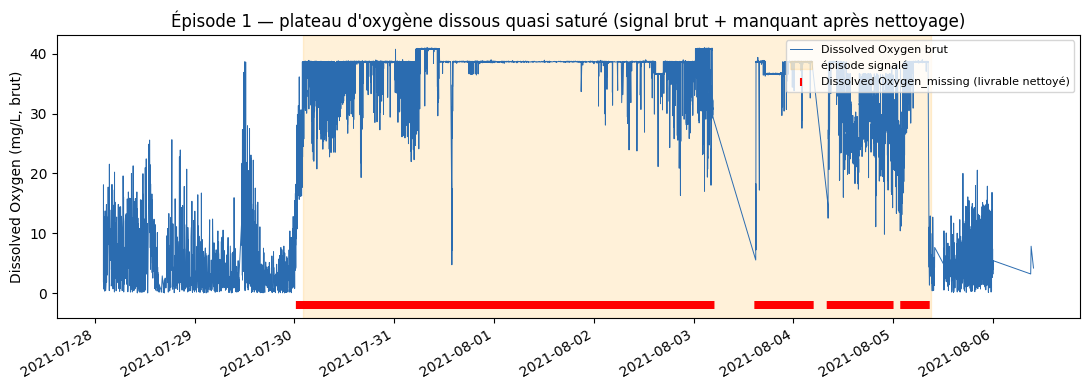

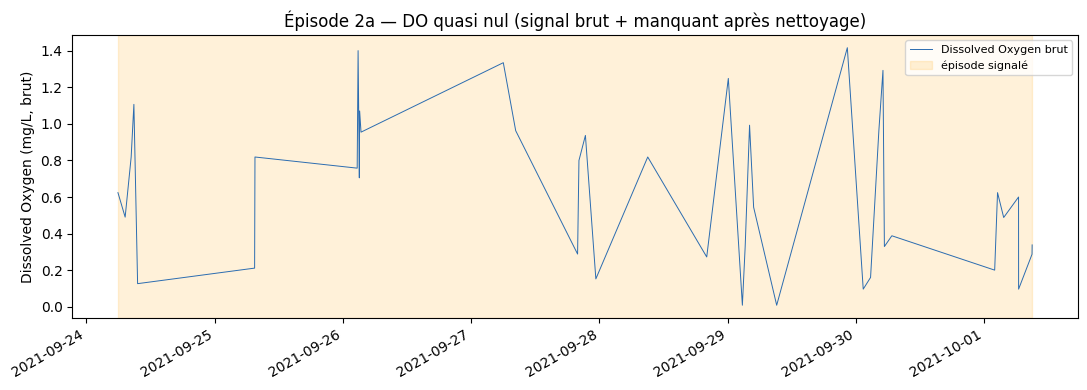

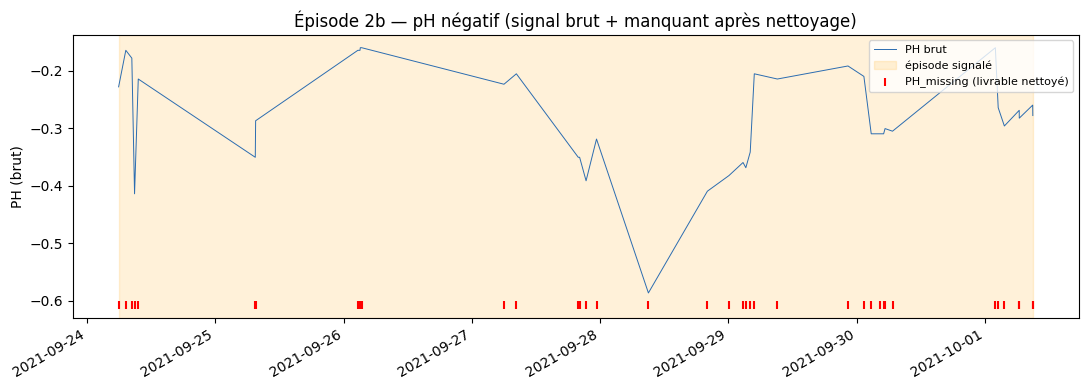

In [5]:
hourly = features.resample_hourly(clean_df)


def plot_episode_raw_with_missing(raw_col, label, start, end, title, fname, ylabel, pad="2D"):
    pad_td = pd.Timedelta(pad)
    lo, hi = pd.Timestamp(start) - pad_td, pd.Timestamp(end) + pad_td
    window_raw = raw_df[(raw_df[config.TIMESTAMP_COLUMN] >= lo) & (raw_df[config.TIMESTAMP_COLUMN] <= hi)]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(window_raw[config.TIMESTAMP_COLUMN], window_raw[raw_col], color="#2b6cb0", linewidth=0.7, label=f"{label} brut")
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="orange", alpha=0.15, label="épisode signalé")

    missing_col = f"{label}_missing"
    if missing_col in clean_df.columns:
        window_clean = clean_df[(clean_df[config.TIMESTAMP_COLUMN] >= lo) & (clean_df[config.TIMESTAMP_COLUMN] <= hi)]
        missing_times = window_clean.loc[window_clean[missing_col], config.TIMESTAMP_COLUMN]
        if len(missing_times):
            y0 = ax.get_ylim()[0]
            ax.scatter(missing_times, [y0] * len(missing_times), marker="|", color="red", s=40,
                       label=f"{label}_missing (livrable nettoyé)")

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper right", fontsize=8)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / fname, bbox_inches="tight")
    plt.show()


plot_episode_raw_with_missing(
    "Dissolved Oxygen(g/ml)", "Dissolved Oxygen", "2021-07-30 02:00:00", "2021-08-05 09:00:00",
    "Épisode 1 — plateau d'oxygène dissous quasi saturé (signal brut + manquant après nettoyage)",
    "jalon2_anomalie_episode1_do_plateau.png", "Dissolved Oxygen (mg/L, brut)",
)

plot_episode_raw_with_missing(
    "Dissolved Oxygen(g/ml)", "Dissolved Oxygen", "2021-09-24 05:55:28", "2021-10-01 08:57:37",
    "Épisode 2a — DO quasi nul (signal brut + manquant après nettoyage)",
    "jalon2_anomalie_episode2a_do_crise.png", "Dissolved Oxygen (mg/L, brut)",
)

plot_episode_raw_with_missing(
    "PH", "PH", "2021-09-24 05:55:28", "2021-10-01 08:57:37",
    "Épisode 2b — pH négatif (signal brut + manquant après nettoyage)",
    "jalon2_anomalie_episode2b_ph_crise.png", "PH (brut)",
)


**Lecture.** Sur l'épisode 1 (signal brut), le DO bascule d'un régime bas habituel
(quelques mg/L) à un plateau soutenu à 36-41 mg/L pendant près de 6 jours, avant de retomber
brutalement — nettement visible à l'œil. Les marques rouges couvrent **toute la largeur** de
l'épisode signalé : dans le livrable nettoyé, cette période entière est `Dissolved
Oxygen_missing = True`, sans aucune valeur exploitable (conséquence directe de la borne à 15
mg/L, ADR-010). Sur l'épisode 2a, le DO brut s'effondre quasiment à zéro (minimum 0,008 le
29/09) — et reste très majoritairement **dans les bornes** de nettoyage : cette partie de la
crise **reste visible** dans le livrable nettoyé (peu de marques rouges), contrairement à
l'épisode 1. Sur l'épisode 2b, constat encore plus net : **la fenêtre brute (padding de 2 jours
inclus) ne contient que 40 relevés au total, tous colonnes confondues, et les 40 ont un pH
négatif** — c'est-à-dire que, pendant cette période de connectivité très dégradée, chaque relevé
qui a effectivement atteint le fichier porte une valeur de pH corrompue, sans aucune exception
(vérifié par comptage direct sur `data/raw/IoTpond1.csv`, pas une estimation). Les marques
rouges couvrent donc l'intégralité des points affichés : les 40 disparaissent du livrable
nettoyé (hors bornes [0, 14], trous d'encadrement > 1h). **Conséquence pour le Jalon 3/5** :
l'épisode 2 (DO) est le meilleur candidat pour une démonstration fondée sur le livrable nettoyé ;
l'épisode 1 et la composante pH de l'épisode 2, eux, ne sont démontrables qu'à partir du signal
brut ou de la détection de leur propre absence (`Dissolved Oxygen_missing`, `PH_missing`), pas
d'un seuil de valeur sur les données nettoyées.

## 3. Corrélations entre qualité d'eau et croissance

`ingestion.rebuild_growth_curve` ne garde que les paliers réels (81 changements de
`Fish_Weight`/`Fish_Length` sur 83 126 lignes). `features.compute_growth_rate` calcule le taux
entre paliers consécutifs. Pour comparer à la qualité d'eau **sans fuite future**, chaque palier
est associé à la moyenne horaire de qualité d'eau du créneau **au moment du palier ou juste
avant** (`merge_asof(..., direction="backward")` — jamais `"forward"`).

**Avertissement méthodologique, à respecter dans l'interprétation ci-dessous** : la croissance
et plusieurs variables de qualité d'eau (nitrate notamment) augmentent *toutes deux* de façon
quasi monotone sur le cycle — une corrélation forte entre niveaux peut donc être une simple
coïncidence temporelle (confusion), pas un lien causal. On regarde donc à la fois les niveaux
et le taux de croissance (`Fish_Weight_growth_rate`), moins soumis à cette dérive commune.


In [6]:
growth_curve = ingestion.rebuild_growth_curve(clean_df)
growth_with_rate = features.compute_growth_rate(growth_curve)

water_quality_cols = [f"{meta['label']}_mean" for meta in config.SENSOR_TYPES.values()]
merged = pd.merge_asof(
    growth_with_rate.sort_values(config.TIMESTAMP_COLUMN),
    hourly[[config.TIMESTAMP_COLUMN, *water_quality_cols,
            *[f"{meta['label']}_n_measured" for meta in config.SENSOR_TYPES.values()]]]
        .sort_values(config.TIMESTAMP_COLUMN),
    on=config.TIMESTAMP_COLUMN,
    direction="backward",
)
print(f"Paliers de croissance : {len(growth_curve)} | fusionnés avec la qualité d'eau (asof, backward) : {len(merged)}")
merged[[config.TIMESTAMP_COLUMN, "Fish_Weight(g)", "Fish_Weight_growth_rate", *water_quality_cols]].head()


rebuild_growth_curve : 3 non-monotonie(s) détectée(s) sur Fish_Length(cm), signalée(s) dans 'Fish_Length_non_monotonic' sans correction : [{'created_at': Timestamp('2021-07-15 00:02:47'), 'Fish_Length(cm)': 15.31}, {'created_at': Timestamp('2021-08-22 01:43:01'), 'Fish_Length(cm)': 23.4}, {'created_at': Timestamp('2021-09-05 00:07:20'), 'Fish_Length(cm)': 12.09}]


Paliers de croissance : 81 | fusionnés avec la qualité d'eau (asof, backward) : 81


,created_at,Fish_Weight(g),Fish_Weight_growth_rate,Temperature_mean,PH_mean,Dissolved Oxygen_mean,Ammonia_mean,Nitrate_mean,Turbidity_mean
0,2021-06-19 00:00:05,2.91,NaN,24.851799,8.433510,5.841159,0.45842,189.734848,100.0
1,2021-06-20 00:00:30,3.85,0.039155,25.895677,8.399412,8.603992,0.45842,195.112782,100.0
2,2021-06-21 00:00:17,4.79,0.039173,25.827178,8.399566,8.248293,0.45842,173.946970,100.0
3,2021-06-22 14:00:41,5.73,0.024733,24.755777,8.334581,11.606985,0.45842,146.243697,100.0
4,2021-06-23 00:00:06,6.67,0.094091,24.912879,8.332507,7.378591,0.45842,149.734848,100.0


In [7]:
rows = []
for meta in config.SENSOR_TYPES.values():
    label = meta["label"]
    mean_col = f"{label}_mean"
    n_measured_col = f"{label}_n_measured"
    for target_col, target_name in (("Fish_Weight(g)", "niveau (Fish_Weight)"),
                                     ("Fish_Weight_growth_rate", "taux (growth_rate)")):
        pair = merged[[mean_col, target_col]].dropna()
        n = len(pair)
        r = pair[mean_col].corr(pair[target_col]) if n >= 3 else float("nan")
        coverage = merged[n_measured_col].gt(0).mean() if n_measured_col in merged else float("nan")
        rows.append({
            "variable": label, "cible": target_name, "n_paires": n,
            "pearson_r": round(r, 3) if pd.notna(r) else None,
            "part_paliers_avec_mesure_reelle": round(coverage, 3) if pd.notna(coverage) else None,
        })

corr_table = pd.DataFrame(rows)
corr_table


,variable,cible,n_paires,pearson_r,part_paliers_avec_mesure_reelle
0,Temperature,niveau (Fish_Weight),81,0.355,1.000
1,Temperature,taux (growth_rate),80,0.126,1.000
2,PH,niveau (Fish_Weight),73,-0.887,0.901
3,PH,taux (growth_rate),72,-0.593,0.901
4,Dissolved Oxygen,niveau (Fish_Weight),76,-0.703,0.938
5,Dissolved Oxygen,taux (growth_rate),75,-0.598,0.938
6,Ammonia,niveau (Fish_Weight),56,0.563,0.691
7,Ammonia,taux (growth_rate),55,0.362,0.691
8,Nitrate,niveau (Fish_Weight),81,0.764,1.000
9,Nitrate,taux (growth_rate),80,0.483,1.000


**Lecture, avec effectifs.** Les corrélations ci-dessus portent sur au plus **81 paliers**
(souvent moins, une fois les créneaux sans mesure exclus par `dropna()`) — un échantillon trop
petit pour une significativité statistique robuste, et deux des six variables (ammoniac,
nitrate) sont des capteurs de gaz dont la valeur absolue n'est qu'un indicateur relatif
(ADR-009). La colonne `part_paliers_avec_mesure_reelle` rappelle, pour l'ammoniac et le DO
notamment, que plusieurs paliers ne portent aucune mesure réelle du tout dans le créneau
horaire correspondant — la corrélation calculée sur les points restants ne représente donc
qu'une fraction discontinue du cycle. Les corrélations de **niveau** (température, nitrate,
turbidité vs `Fish_Weight`) sont attendues fortes par construction (les deux croissent avec le
temps du cycle, confusion déjà signalée) et ne doivent pas être lues comme un effet causal de la
qualité d'eau sur la croissance. Les corrélations de **taux** (`growth_rate`) sont la lecture la
plus honnête de ce dataset : elles restent faibles, ce qui est cohérent avec un taux de
croissance dominé par la biologie du cycle (poids croissant avec l'âge) plutôt que par des
variations de qualité d'eau à cette granularité horaire et sur seulement 81 paliers.

## 4. Couverture temporelle réelle

Relevés bruts par jour sur tout le cycle, et part de créneaux horaires portant une valeur
réellement mesurée (pas seulement imputée) pour chaque variable bornée.


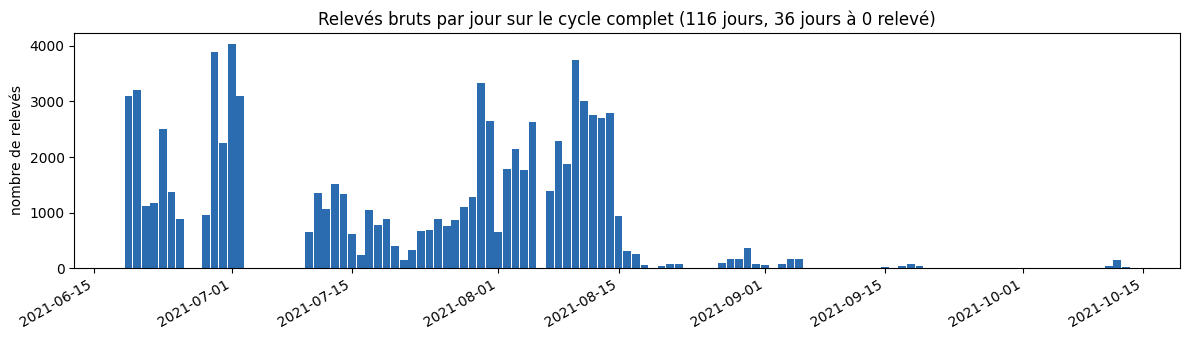

Jours calendaires couverts : 117 | jours sans aucun relevé : 36 (30.77%)


In [8]:
daily_counts = raw_df.set_index(config.TIMESTAMP_COLUMN).resample("1D").size()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(daily_counts.index, daily_counts.values, width=0.9, color="#2b6cb0")
ax.set_title("Relevés bruts par jour sur le cycle complet (116 jours, 36 jours à 0 relevé)")
ax.set_ylabel("nombre de relevés")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "jalon2_couverture_temporelle_journaliere.png", bbox_inches="tight")
plt.show()

n_days_empty = int((daily_counts == 0).sum())
print(f"Jours calendaires couverts : {len(daily_counts)} | jours sans aucun relevé : {n_days_empty} "
      f"({n_days_empty / len(daily_counts):.2%})")


In [9]:
total_slots = len(hourly)
coverage_rows = []
for meta in config.SENSOR_TYPES.values():
    label = meta["label"]
    n_measured_col = f"{label}_n_measured"
    slots_with_measure = int((hourly[n_measured_col] > 0).sum())
    coverage_rows.append({
        "variable": label,
        "créneaux horaires totaux": total_slots,
        "créneaux avec >=1 mesure réelle": slots_with_measure,
        "couverture": round(slots_with_measure / total_slots, 4),
    })
pd.DataFrame(coverage_rows)


,variable,créneaux horaires totaux,créneaux avec >=1 mesure réelle,couverture
0,Temperature,2789,1431,0.5131
1,PH,2789,1400,0.5020
2,Dissolved Oxygen,2789,1301,0.4665
3,Ammonia,2789,980,0.3514
4,Nitrate,2789,1431,0.5131
5,Turbidity,2789,1431,0.5131


**Lecture.** 36 des 117 jours calendaires de l'étendue (30,77 %) n'ont strictement aucun
relevé, concentrés en quelques coupures longues (7-10 jours) déjà datées dans
`reports/analyse-donnees-jalon1.md` §8. Cette structure de trous n'est pas aléatoire : elle
coïncide en partie avec les épisodes atypiques (§2), ce qui doit être gardé en tête pour le
Jalon 3 (biais de sélection déjà signalé dans `reports/validations/jalon-1.md` §4).

## 5. Démonstration des features causales (`src/features.py`)

Bref aperçu des 4 fonctions sur les données réelles, pour vérifier visuellement l'absence de
fuite temporelle (`add_rolling_features`) et la convention de signe (`add_threshold_distance`).


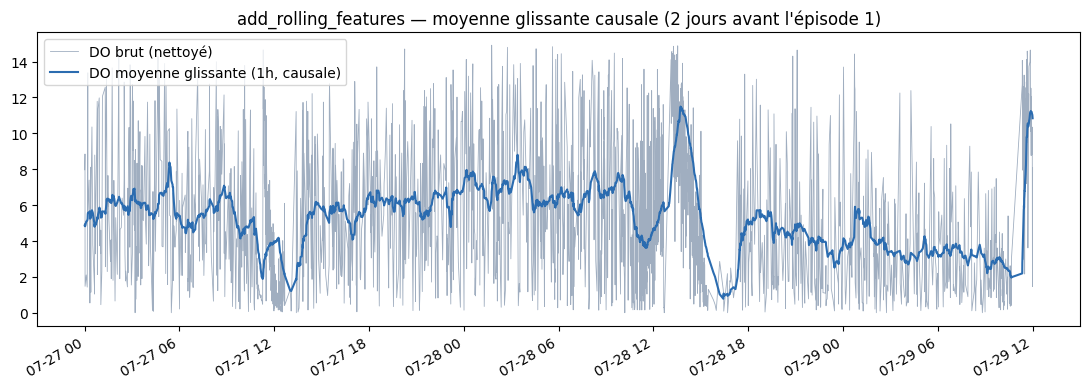

In [10]:
rolled = features.add_rolling_features(clean_df, window=config.ROLLING_WINDOW_DEFAULT)

# Fenêtre choisie juste AVANT l'épisode 1 (§2) : le DO y fluctue normalement
# et reste dans les bornes de nettoyage (contrairement au plateau du 30/07 au
# 05/08, entièrement manquant dans le livrable nettoyé) — la démonstration
# de la moyenne glissante a donc un signal réel à suivre sur toute la fenêtre.
window_start, window_end = "2021-07-27", "2021-07-29 12:00:00"
zoom = rolled[(rolled[config.TIMESTAMP_COLUMN] >= window_start) & (rolled[config.TIMESTAMP_COLUMN] <= window_end)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(zoom[config.TIMESTAMP_COLUMN], zoom["Dissolved Oxygen(g/ml)"], color="#a0aec0", label="DO brut (nettoyé)", linewidth=0.6)
ax.plot(zoom[config.TIMESTAMP_COLUMN], zoom["Dissolved Oxygen_rolling_mean"], color="#2b6cb0", label=f"DO moyenne glissante ({config.ROLLING_WINDOW_DEFAULT}, causale)")
ax.set_title("add_rolling_features — moyenne glissante causale (2 jours avant l'épisode 1)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "jalon2_demo_rolling_features.png", bbox_inches="tight")
plt.show()


In [11]:
water_quality_renamed = clean_df.rename(columns={
    raw_col: meta["threshold_key"] for raw_col, meta in config.SENSOR_TYPES.items()
})
distance_df = features.add_threshold_distance(water_quality_renamed, config.THRESHOLDS)
distance_cols = [c for c in distance_df.columns if c.endswith("_distance_critical")]
print("Colonnes produites :", distance_cols)
distance_df[distance_cols].describe()


Colonnes produites : ['temperature_distance_critical', 'dissolved_oxygen_distance_critical', 'ph_distance_critical']


,temperature_distance_critical,dissolved_oxygen_distance_critical,ph_distance_critical
count,83126.000000,69883.000000,83086.000000
mean,4.575117,3.044510,1.120924
std,0.682183,3.793824,0.337116
min,3.000000,-2.993000,-4.856730
25%,4.125000,-0.117000,1.089960
50%,4.562500,2.443000,1.158060
75%,4.937500,5.807000,1.307860
max,7.500000,11.994000,1.498520


**Lecture.** Seules `temperature_distance_critical`, `ph_distance_critical` et
`dissolved_oxygen_distance_critical` sont produites — jamais `ammonia`/`nitrate` (capteurs de
gaz, ADR-009) ni `turbidity` (seuil non tranché, §6). Sur la fenêtre zoomée (2 jours précédant
l'épisode 1), la moyenne glissante du DO suit fidèlement le signal brut fluctuant avec un léger
retard (effet attendu d'une fenêtre causale d'1h), sans jamais anticiper une valeur future.

## 6. Matière factuelle pour deux décisions ouvertes (non tranchées ici)

Ces deux points restent des **décisions à trancher par l'humain (G1)** — cette section fournit
des chiffres recalculés sur le livrable nettoyé, pas une décision. Recommandation motivée dans
le compte rendu de l'agent et dans `reports/analyse-donnees-jalon1.md` (note datée).


In [12]:
ph_series = clean_df["PH"]
n_ph_below_4 = int((ph_series < 4).sum())
n_ph_total_valid = int(ph_series.notna().sum())
ph_below_4_dates = clean_df.loc[ph_series < 4, config.TIMESTAMP_COLUMN]
print(f"pH < 4 dans le livrable nettoyé : {n_ph_below_4} / {n_ph_total_valid} valeurs valides "
      f"({n_ph_below_4 / n_ph_total_valid:.3%})")
print(f"Fenêtre : {ph_below_4_dates.min()} -> {ph_below_4_dates.max()}")
print("Jours distincts concernés :", sorted(ph_below_4_dates.dt.date.unique().tolist()))


pH < 4 dans le livrable nettoyé : 145 / 83086 valeurs valides (0.175%)
Fenêtre : 2021-09-15 18:37:43 -> 2021-10-13 04:14:22
Jours distincts concernés : [datetime.date(2021, 9, 15), datetime.date(2021, 9, 16), datetime.date(2021, 9, 17), datetime.date(2021, 9, 18), datetime.date(2021, 9, 19), datetime.date(2021, 10, 11), datetime.date(2021, 10, 12), datetime.date(2021, 10, 13)]


Turbidité exactement à 100 (plafond de l'échelle) : 46854 / 83126 (56.37%)
count    83126.000000
mean        87.490160
std         25.859375
min          1.000000
25%         91.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: Turbidity(NTU), dtype: float64


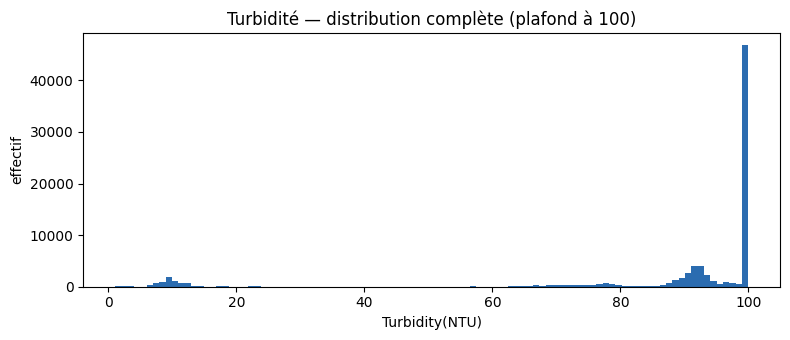

In [13]:
turbidity = clean_df["Turbidity(NTU)"]
n_at_ceiling = int((turbidity == 100).sum())
print(f"Turbidité exactement à 100 (plafond de l'échelle) : {n_at_ceiling} / {len(turbidity)} "
      f"({n_at_ceiling / len(turbidity):.2%})")
print(turbidity.describe())

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(turbidity, bins=100, color="#2b6cb0")
ax.set_title("Turbidité — distribution complète (plafond à 100)")
ax.set_xlabel("Turbidity(NTU)")
ax.set_ylabel("effectif")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "jalon2_turbidite_distribution.png", bbox_inches="tight")
plt.show()


**pH — resserrement à une plage réaliste.** 145 relevés < 4 subsistent dans le livrable
nettoyé (0,17 % des valeurs valides), répartis en **deux groupes, pas une fenêtre continue** :
62 le 15-19/09 (4, 10, 13, 24, 11) **juste avant** l'épisode 2, et 83 le 11-13/10 (17, 47, 19)
**juste après** la coupure de connexion de 10 jours qui suit l'épisode 2 — **aucun le 20/09-
10/10**, la fenêtre de pH négatif elle-même (24/09-01/10, §2) est vide de ces 145 valeurs : les
40 pH négatifs qui s'y trouvaient sont hors bornes ([0, 14]) et donc absents du livrable nettoyé
(marqués manquants, cf. `reports/analyse-donnees-jalon1.md` §6). Les 145 encadrent donc
l'épisode 2 sans le recouvrir. **Options** : (a) laisser tel quel (différé, ADR-010) ; (b)
resserrer `PH_BOUNDS` à une plage réaliste (ex. [4, 10] ou [4, 14]) — chiffrable : 145 valeurs de
plus basculeraient en hors-bornes puis en imputé/manquant selon le trou encadrant ; (c) ne
resserrer que dans une future étape de modélisation (garder le nettoyage large, filtrer au
moment de l'usage). **Recommandation motivée (non tranchée)** : option (c) — le nettoyage
physique [0, 14] reste défendable (aucune valeur n'est impossible sur l'échelle pH elle-même), et
ces 145 valeurs, concentrées sur les bords immédiats d'un épisode de capteur déjà identifié, sont
plus utiles **signalées** que supprimées : elles pourraient marquer le début et la fin réels de
la dégradation du capteur (plus large que la seule fenêtre à valeurs négatives), utile au Jalon 3.
Resserrer au nettoyage risquerait de faire disparaître ce signal plutôt qu'un artefact isolé.

**Turbidité — seuil.** 56,37 % des relevés du fichier brut sont exactement à 100 (plafond de
l'échelle) — confirmé à l'identique sur le livrable nettoyé (colonne non modifiée, ADR ouvert).
**Options** : (a) seuil critique = 100 (le plafond lui-même, capturant "capteur saturé" comme
signal) ; (b) un seuil sous 100 (ex. 80 ou 90 NTU, cohérent avec une littérature aquacole
générique sur la turbidité) ; (c) traiter la turbidité comme `ammonia`/`nitrate` — indicateur
relatif, sans seuil absolu, jusqu'à confirmation de la nature du capteur. **Recommandation
motivée (non tranchée)** : option (c) par prudence — plus de la moitié du cycle au plafond
n'est pas distinguable, avec les seules données disponibles, entre "eau réellement très trouble"
et "capteur souvent saturé" (même ambiguïté que pour DO/ammoniac/nitrate, §1 de
`reports/analyse-donnees-jalon1.md`) ; fixer un seuil absolu sur un signal dont on ne sait pas
s'il sature créerait une alerte quasi permanente (56 % du temps), invalidante pour la
démonstration — le même problème déjà rencontré et évité pour le nitrate.

## Synthèse

- Distributions post-nettoyage cohérentes avec les seuils scientifiques pour température/pH/DO ;
  ammoniac/nitrate restent des indicateurs relatifs (ADR-009), jamais comparés à un seuil mg/L absolu.
- Deux épisodes d'anomalie détectables à l'œil, datés précisément et reproduits ici depuis les
  données nettoyées + agrégation horaire causale (§2).
- Corrélations qualité d'eau ↔ croissance calculées et interprétées avec leurs effectifs réels
  (§3) : faibles sur le taux de croissance, ce qui est attendu vu 81 paliers et deux capteurs de
  gaz — documenté comme limite plutôt que masqué (règle d'intégrité académique).
- Couverture temporelle réelle chiffrée (§4) : 36 jours sans relevé, couverture horaire
  inégale par variable (R16).
- Features causales du Module 2 démontrées sans fuite temporelle (§5).
- Matière chiffrée pour pH et turbidité fournie sans trancher (§6), recommandations motivées
  reprises dans le compte rendu de l'agent et dans `reports/analyse-donnees-jalon1.md`.
